In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
file_path = "StravaFullMergedData.csv"
df = pd.read_csv(file_path)

print("Original Shape:", df.shape)
df.head()

Original Shape: (943, 224)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,minute_steps_wide50,minute_steps_wide51,minute_steps_wide52,minute_steps_wide53,minute_steps_wide54,minute_steps_wide55,minute_steps_wide56,minute_steps_wide57,minute_steps_wide58,minute_steps_wide59
0,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,116,75,0,0,0,0,0,0,0,0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1844505072,2016-05-04,2080,1.37,1.37,0.0,0.00,0.00,1.37,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1844505072,2016-05-04,2080,1.37,1.37,0.0,0.00,0.00,1.37,0.0,...,35,64,32,36,0,0,0,0,0,0


In [3]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance',
       ...
       'minute_steps_wide50', 'minute_steps_wide51', 'minute_steps_wide52',
       'minute_steps_wide53', 'minute_steps_wide54', 'minute_steps_wide55',
       'minute_steps_wide56', 'minute_steps_wide57', 'minute_steps_wide58',
       'minute_steps_wide59'],
      dtype='str', length=224)

In [4]:
df.isnull().sum()

Id                     0
ActivityDate           0
TotalSteps             0
TotalDistance          0
TrackerDistance        0
                      ..
minute_steps_wide55    0
minute_steps_wide56    0
minute_steps_wide57    0
minute_steps_wide58    0
minute_steps_wide59    0
Length: 224, dtype: int64

In [7]:
if "ActivityDate" in df.columns:
    df["ActivityDate"] = pd.to_datetime(df["ActivityDate"], errors="coerce")

df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,minute_steps_wide50,minute_steps_wide51,minute_steps_wide52,minute_steps_wide53,minute_steps_wide54,minute_steps_wide55,minute_steps_wide56,minute_steps_wide57,minute_steps_wide58,minute_steps_wide59
0,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,116,75,0,0,0,0,0,0,0,0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1844505072,2016-05-04,2080,1.37,1.37,0.0,0.00,0.00,1.37,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1844505072,2016-05-04,2080,1.37,1.37,0.0,0.00,0.00,1.37,0.0,...,35,64,32,36,0,0,0,0,0,0


In [8]:
if "Id" in df.columns and "ActivityDate" in df.columns:
    df_daily = df.drop_duplicates(subset=["Id", "ActivityDate"]).copy()
else:
    df_daily = df.copy()

print("Original Shape:", df.shape)
print("Daily-Level Shape:", df_daily.shape)

Original Shape: (943, 224)
Daily-Level Shape: (43, 224)


In [9]:
df_daily.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,minute_steps_wide50,minute_steps_wide51,minute_steps_wide52,minute_steps_wide53,minute_steps_wide54,minute_steps_wide55,minute_steps_wide56,minute_steps_wide57,minute_steps_wide58,minute_steps_wide59
count,4.300000e+01,43,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,...,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,4.066710e+09,2016-04-25 12:50:13.953488,8607.767442,6.190465,6.167674,0.114933,2.304884,0.692093,3.190465,0.000233,...,7.767442,6.162791,5.232558,5.651163,8.488372,7.883721,5.534884,5.279070,5.674419,9.744186
min,1.503960e+09,2016-04-13 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.844505e+09,2016-04-17 00:00:00,2630.000000,1.675000,1.675000,0.000000,0.000000,0.000000,1.675000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.372868e+09,2016-04-21 00:00:00,9762.000000,6.480000,6.480000,0.000000,1.340000,0.420000,2.830000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.577150e+09,2016-05-03 12:00:00,12567.000000,8.865000,8.865000,0.000000,2.950000,0.770000,4.870000,0.000000,...,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.877689e+09,2016-05-12 00:00:00,22770.000000,19.560000,19.560000,4.942140,13.220000,5.120000,6.200000,0.010000,...,116.000000,75.000000,83.000000,70.000000,75.000000,93.000000,101.000000,120.000000,123.000000,123.000000
std,2.631640e+09,NaN,5793.330109,4.553273,4.533702,0.753669,3.051134,1.039209,1.934745,0.001525,...,21.142191,17.023695,16.788371,14.037168,19.963505,20.009771,17.666688,20.102506,22.341208,24.946698


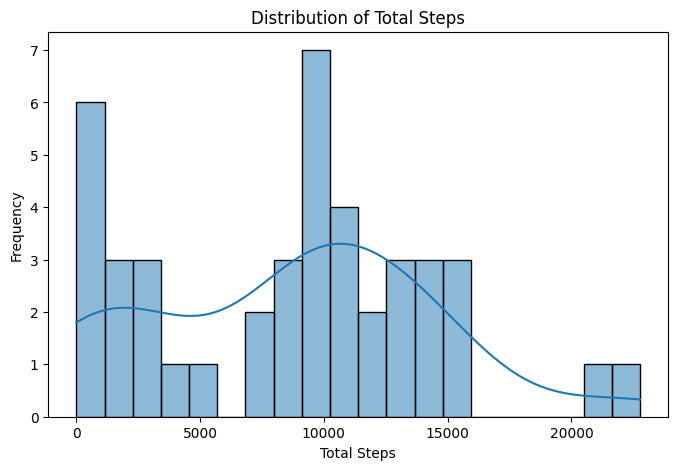

In [10]:
if "TotalSteps" in df_daily.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_daily["TotalSteps"].dropna(), bins=20, kde=True)
    plt.title("Distribution of Total Steps")
    plt.xlabel("Total Steps")
    plt.ylabel("Frequency")
    plt.show()

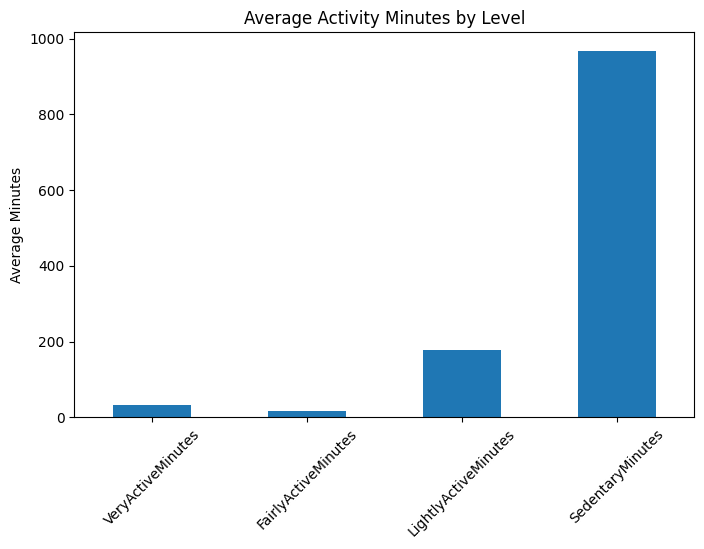

In [11]:
activity_cols = ["VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes", "SedentaryMinutes"]
available_activity_cols = [col for col in activity_cols if col in df_daily.columns]

if available_activity_cols:
    activity_means = df_daily[available_activity_cols].mean()
    plt.figure(figsize=(8, 5))
    activity_means.plot(kind="bar")
    plt.title("Average Activity Minutes by Level")
    plt.ylabel("Average Minutes")
    plt.xticks(rotation=45)
    plt.show()

In [16]:
if "ActivityDate" in df_daily.columns and "TotalSteps" in df_daily.columns and "Calories" in df_daily.columns:
    timeline_df = df_daily.sort_values("ActivityDate")
    plt.figure(figsize=(10, 5))
    plt.plot(timeline_df["ActivityDate"], timeline_df["TotalSteps"], label="Total Steps")
    plt.plot(timeline_df["ActivityDate"], timeline_df["Calories"], label="Calories")
    plt.title("Steps and Calories Over Time")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

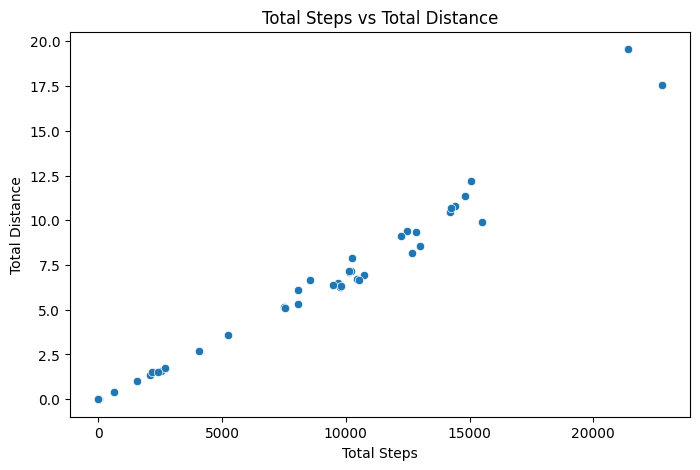

In [14]:
if "TotalSteps" in df_daily.columns and "TotalDistance" in df_daily.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_daily, x="TotalSteps", y="TotalDistance")
    plt.title("Total Steps vs Total Distance")
    plt.xlabel("Total Steps")
    plt.ylabel("Total Distance")
    plt.show()

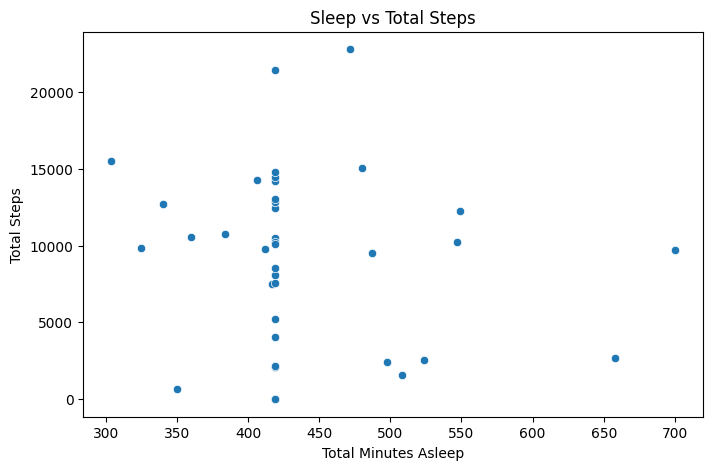

In [15]:
if "TotalMinutesAsleep" in df_daily.columns and "TotalSteps" in df_daily.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_daily, x="TotalMinutesAsleep", y="TotalSteps")
    plt.title("Sleep vs Total Steps")
    plt.xlabel("Total Minutes Asleep")
    plt.ylabel("Total Steps")
    plt.show()

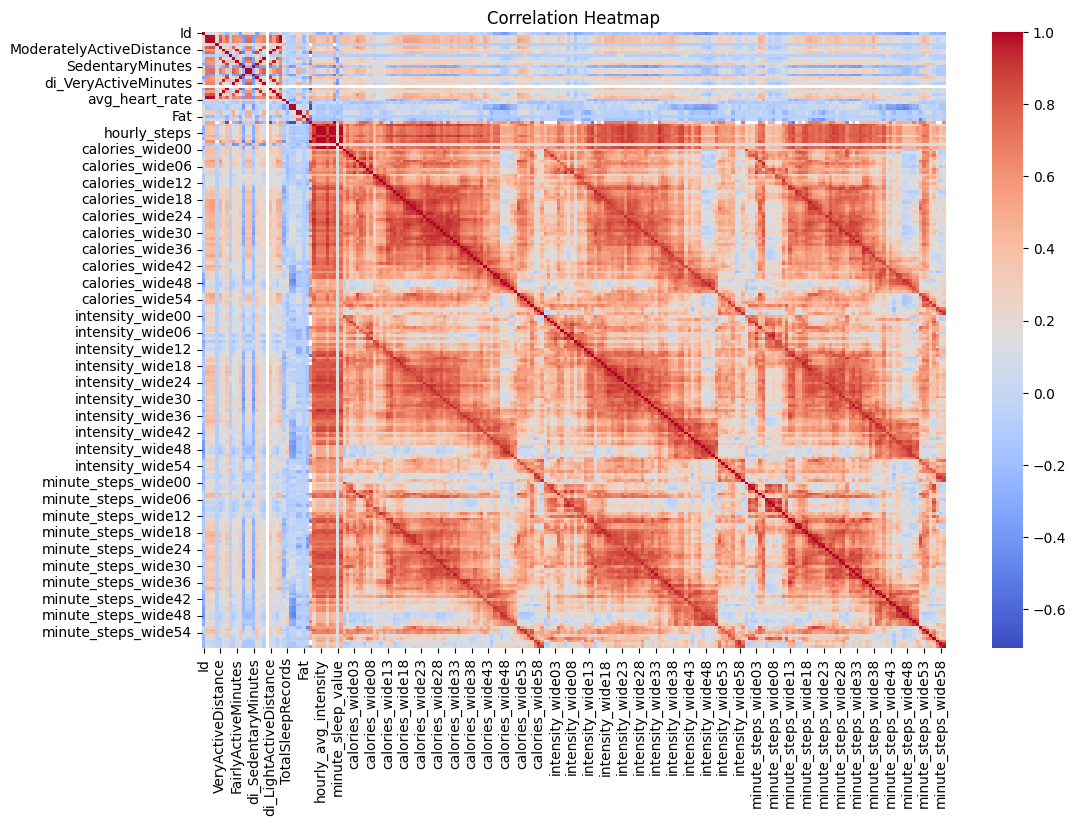

In [17]:
numeric_df = df_daily.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df_daily.to_csv("Strava_daily_level_cleaned.csv", index=False)
print("Cleaned daily-level data saved successfully.")

Cleaned daily-level data saved successfully.
